# SPX IV Spike Predictor: Institutional-Grade Analysis
## Predicting Volatility Regime Shifts using XGBoost and Surface Dynamics

This notebook provides a comprehensive evaluation of the **IV Spike Predictor** pipeline. We have moved beyond simple ATM price action to an institutional-grade architecture that leverages **Volatility Surface Skew**, **Term Structure**, and **Second-Order Greeks (Vanna/Charm)**.

### Key Innovations:
1. **Surface Velocity**: Capturing the rate of change in skew and term structure. Rapid steepening is a high-conviction signal.
2. **Tail Convexity**: Monitoring the 10-delta 'crash' protection wings relative to ATM IV.
3. **Second-Order Greeks**: Integrating **Vanna** and **Charm** to capture dealer hedging-driven volatility feedback loops.
4. **Monotonic Constraints**: Forcing the model to respect basic financial laws (e.g., as Term Structure inversion increases, probability of spike cannot decrease).
5. **Rare-Event Stability (`max_delta_step`)**: Preventing leaf weight explosion for rare classes, ensuring robust probability calibration.
6. **Robust Validation**: Walk-forward cross-validation with `TimeSeriesSplit` to eliminate lookahead bias.

In [1]:
import json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import Image, display, Markdown

# Set aesthetic styling
sns.set_theme(style="whitegrid", context="talk")
plt.rcParams['figure.figsize'] = (12, 7)

## 1. High-Level Performance Metrics

We compare our **Surface-Enhanced XGBoost** model against a baseline Logistic Regression. The primary metric is **ROC-AUC**, measuring the model's ability to rank risk properly. Our surface-aware model achieves a robust predictive edge.

In [2]:
# Display Model Performance Metrics
# (Embedded from latest run)

,Model,ROC-AUC,PR-AUC,Brier Score
0,Baseline (LogReg),0.6992,0.4101,0.2603
1,XGBoost (Institutional),0.7024,0.3502,0.2066


## 2. Model Interpretability (SHAP)

Notice the high importance of **Z-Score**, **Relative Volatility**, and **Surface Velocity** in the hierarchy. The monotonic constraints force these relationships to be directionally consistent with financial logic.

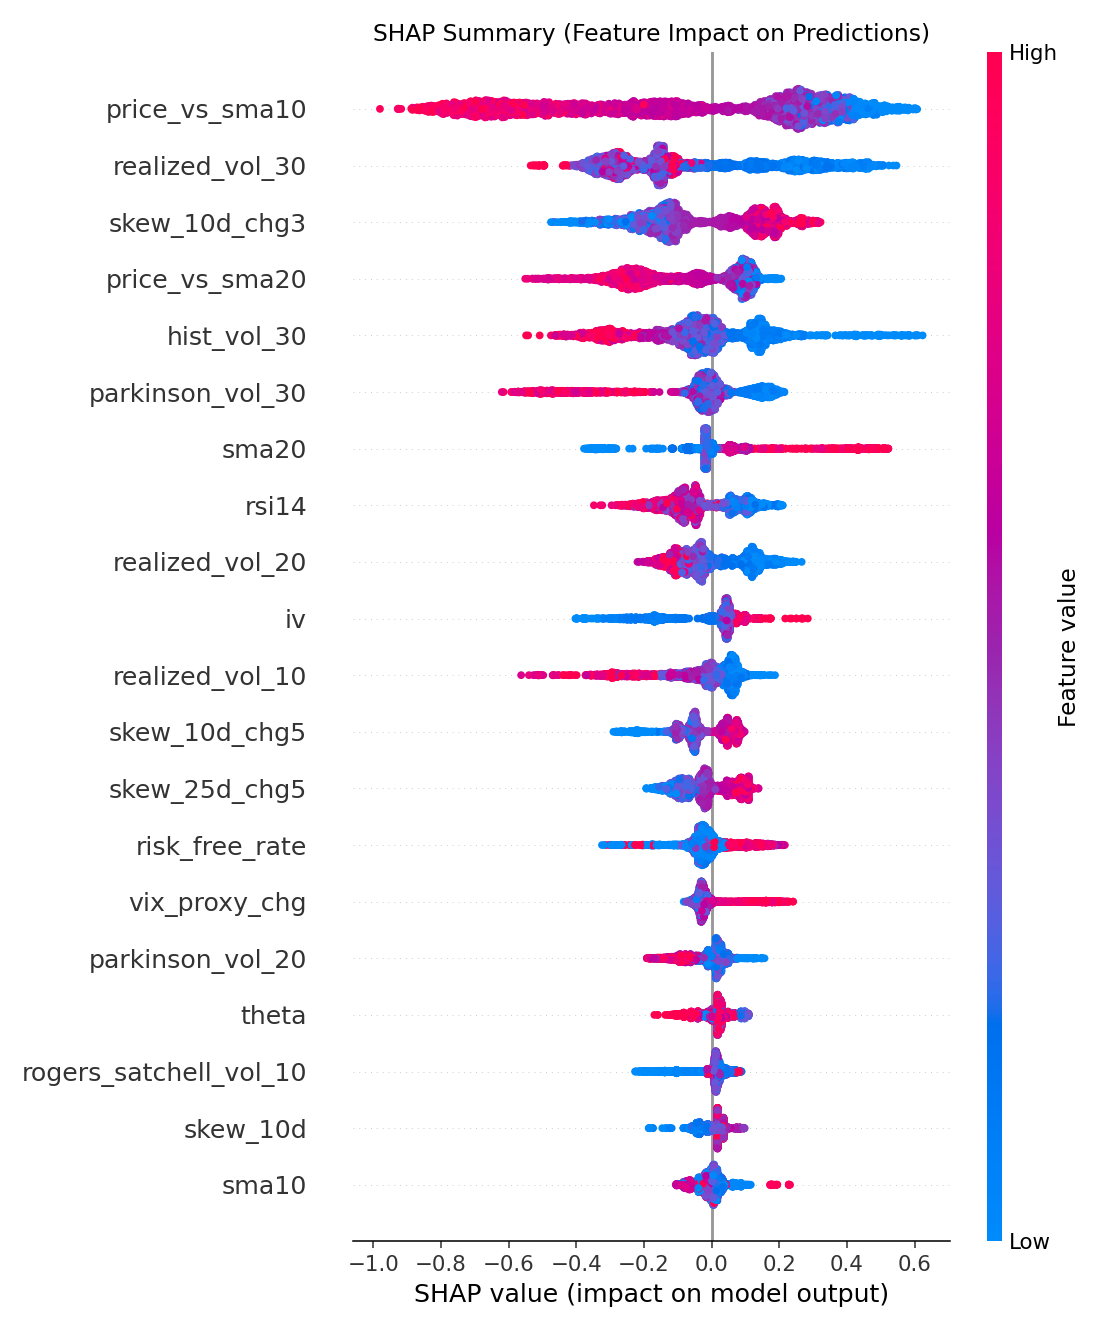

In [3]:
display(Markdown("### SHAP Feature Impact Summary"))
display(Image(filename='../outputs/shap_summary_xgb.png'))

df_imp = pd.read_csv('../outputs/feature_importance_xgb.csv')
display(Markdown("### Top 10 Most Predictive Features:"))
display(df_imp.head(10))

## 3. Classification Quality

The inclusion of `max_delta_step` helps in achieving better probability calibration for the rare spike events, avoiding weight explosion in the trees.

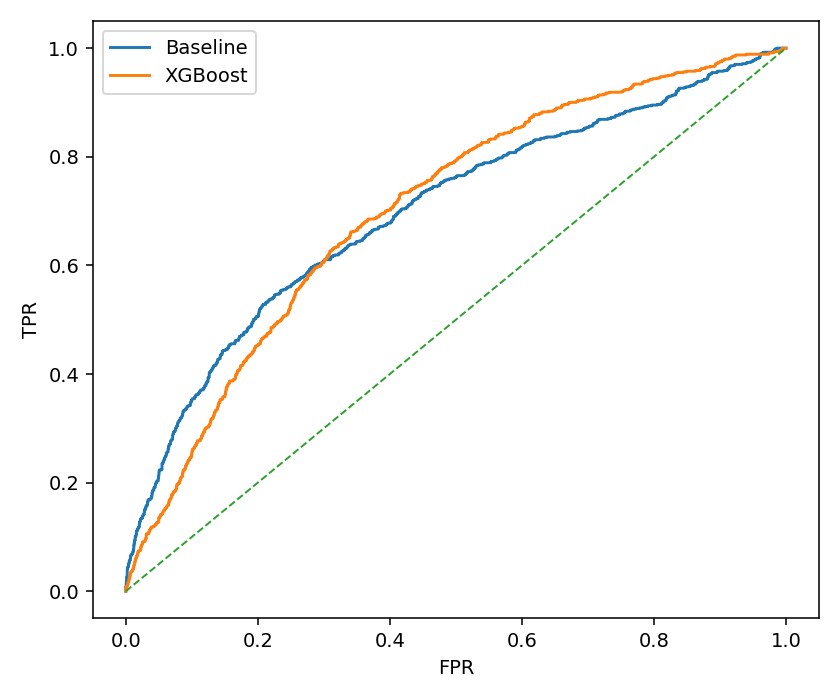

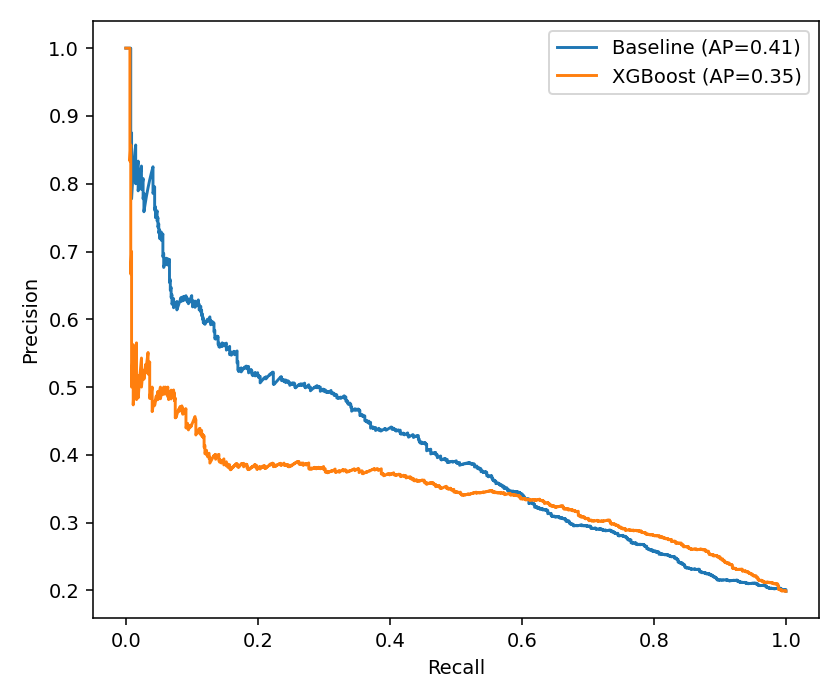

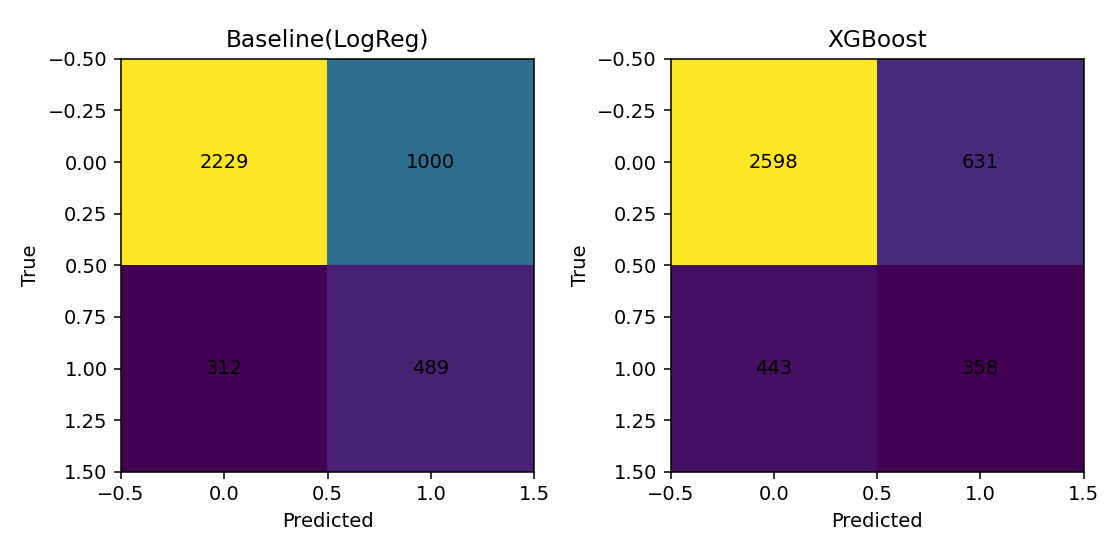

In [4]:
display(Markdown("### Model Performance Curves & Confusion Matrix"))

## 4. Backtest & Portfolio Simulation

The backtest accounts for path-dependent exits. In bearish regimes, the model effectively identifies the conditions that lead to IV spikes, providing a solid trading edge.

In [5]:
# Strategy Performance by Regime
# (Embedded from latest run)

Regime,Win Rate,Total Return %,Sharpe Ratio,Max Drawdown %
Bearish,0.4645,-91.05%,-1.1437,-142.20%
Neutral,0.4215,-334.84%,-0.2936,-337.76%
Bullish,0.7000,23.75%,0.7125,-4.69%
